In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("../data/model1_dataset.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df

,Driver,Position,Time,Team,Compound,TyreLife,LapTime,mean_last_5,median_last_5,mean_last_3,...,p_plus1_LapTime,p_plus2_LapTime,p_plus3_LapTime,target,p_minus1_exists,p_minus2_exists,p_minus3_exists,p_plus1_exists,p_plus2_exists,p_plus3_exists
0,VER,1,4055.587,Red Bull Racing,MEDIUM,5.0,93.955,94.2924,94.043,93.917333,...,94.085,94.382,94.557,-1,0,0,0,1,1,1
1,PER,2,4058.048,Red Bull Racing,MEDIUM,5.0,94.085,94.7846,94.085,94.062000,...,94.382,94.557,94.512,-2,1,0,0,1,1,1
2,ALO,5,4062.053,Aston Martin,MEDIUM,6.0,94.512,95.5856,94.746,94.565667,...,94.902,95.150,95.107,-2,1,1,1,1,1,1
3,LEC,3,4059.129,Ferrari,MEDIUM,5.0,94.382,95.0008,94.549,94.714667,...,94.557,94.512,94.902,-2,1,1,0,1,1,1
4,SAR,18,4077.622,Williams,MEDIUM,5.0,96.204,98.6994,96.871,96.539667,...,96.238,193.742,193.742,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87903,SAI,4,7164.090,McLaren,MEDIUM,27.0,57.648,57.4252,57.531,57.348333,...,57.492,57.339,57.448,0,1,1,1,1,1,1
87904,RAI,14,7175.337,Alfa Romeo Racing,SOFT,20.0,57.870,57.9630,57.811,58.071667,...,58.202,58.012,59.696,0,1,1,1,1,1,1
87905,BOT,8,7167.349,Mercedes,HARD,33.0,57.198,57.7038,57.546,57.260667,...,57.590,57.356,57.670,0,1,1,1,1,1,1
87906,AIT,16,7182.909,Williams,SOFT,23.0,58.012,58.2066,58.193,58.141667,...,59.696,116.386,116.386,0,1,1,1,1,0,0


In [32]:
df.describe()

,Position,Time,TyreLife,LapTime,mean_last_5,median_last_5,mean_last_3,median_last_3,p_minus1_time_delta,p_minus2_time_delta,...,p_plus1_LapTime,p_plus2_LapTime,p_plus3_LapTime,target,p_minus1_exists,p_minus2_exists,p_minus3_exists,p_plus1_exists,p_plus2_exists,p_plus3_exists
count,87908.000000,87908.000000,87277.000000,87792.000000,87908.000000,87908.000000,87908.000000,87908.000000,85173.000000,85379.000000,...,84983.000000,85281.000000,86877.000000,87908.000000,87908.000000,87908.000000,87908.000000,87908.000000,87908.000000,87908.000000
mean,9.471356,6351.398691,16.262360,88.410175,89.022193,88.628915,88.693291,88.523415,64.067339,125.589165,...,92.917778,97.634791,103.712481,0.109160,0.942201,0.885767,0.829231,0.951927,0.901317,0.832825
std,5.290717,1942.989964,8.953957,12.251904,12.271318,12.377192,12.258731,12.375292,235.675117,319.150269,...,23.503724,30.443292,36.668317,1.820967,0.233364,0.318096,0.376310,0.213922,0.298237,0.373134
min,1.000000,462.766000,0.000000,56.393000,56.524400,56.514000,56.515000,56.442000,-69.463000,-68.048000,...,55.404000,55.404000,55.404000,-16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,4924.772750,9.000000,80.098000,80.644700,80.212750,80.385000,80.151000,1.166000,3.079000,...,80.592500,81.130000,81.780000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,9.000000,6282.099000,14.000000,86.061000,86.958100,86.190000,86.334833,86.063500,2.500000,6.458000,...,87.291000,89.149000,91.440000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,14.000000,7643.839000,21.000000,96.771000,97.668050,97.092000,97.199667,96.920000,6.241000,15.739000,...,98.273500,99.961000,103.606000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,20.000000,14543.924000,73.000000,149.966000,145.038250,147.449000,147.717500,149.529000,999.000000,999.000000,...,280.436000,280.436000,284.954000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
df.isnull().sum()

Driver                          0
Position                        0
Time                            0
Team                            0
Compound                        0
TyreLife                      631
LapTime                       116
mean_last_5                     0
median_last_5                   0
mean_last_3                     0
median_last_3                   0
p_minus1_time_delta          2735
p_minus2_time_delta          2529
p_minus3_time_delta          2296
p_plus1_time_delta           2925
p_plus2_time_delta           2627
p_plus3_time_delta           1031
p_minus1_mean_LapTime        2735
p_minus2_mean_LapTime        2529
p_minus3_mean_LapTime        2296
p_minus1_median_LapTime      2735
p_minus2_median_LapTime      2529
p_minus3_median_LapTime      2296
p_plus1_mean_LapTime         2925
p_plus2_mean_LapTime         2627
p_plus3_mean_LapTime         1031
p_plus1_median_LapTime       2925
p_plus2_median_LapTime       2627
p_plus3_median_LapTime       1031
p_3_minus1_mea

<Axes: xlabel='TyreLife', ylabel='Count'>

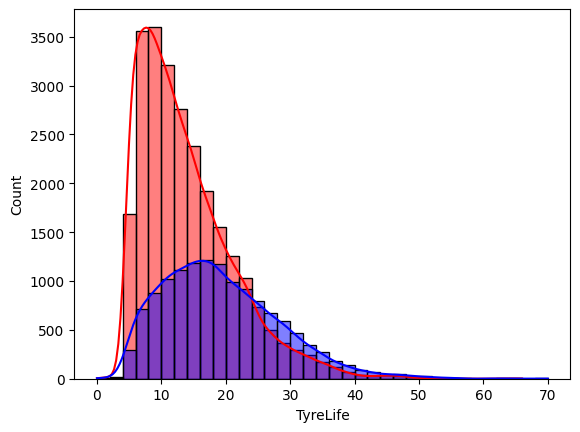

In [34]:
sns.histplot(df[(df["target"]>0)]["TyreLife"], kde=True, binwidth=2, color="red", stat="count")
sns.histplot(df[(df["target"]<0)]["TyreLife"], kde=True, binwidth=2, color="blue", stat="count")


In [35]:
df[df["target"]!=0].shape, df[df["target"]==0].shape 

((39229, 54), (48679, 54))

In [36]:
pd.crosstab(df["Team"], df["Driver"])

Driver,AIT,ALB,ALO,ANT,BEA,BOR,BOT,COL,DEV,DOO,...,RAI,RIC,RUS,SAI,SAR,STR,TSU,VER,VET,ZHO
Team,,,,,,,,,,,,,,,,,,,,,
Alfa Romeo,0,0,0,0,0,0,1438,0,0,0,...,0,0,0,0,0,0,0,0,0,1313
Alfa Romeo Racing,0,0,0,0,0,0,0,0,0,0,...,1284,0,0,0,0,0,0,0,0,0
AlphaTauri,0,0,0,0,0,0,0,0,353,0,...,0,242,0,0,0,0,1994,0,0,0
Alpine,0,0,1459,0,0,0,0,656,0,175,...,0,0,0,0,0,0,0,0,0,0
Aston Martin,0,0,2403,0,0,0,0,0,0,0,...,0,0,0,0,0,3734,0,0,1455,0
Ferrari,0,0,0,0,36,0,0,0,0,0,...,0,0,0,3081,0,0,0,0,546,0
Haas F1 Team,0,0,0,0,952,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Kick Sauber,0,0,0,0,0,783,855,0,0,0,...,0,0,0,0,0,0,0,0,0,836
McLaren,0,0,0,0,0,0,0,0,0,0,...,0,1506,0,553,0,0,0,0,0,0


In [37]:
df.corr(numeric_only=True)["target"]

Position                     0.196348
Time                        -0.025675
TyreLife                    -0.178687
LapTime                     -0.013085
mean_last_5                 -0.012101
median_last_5               -0.011880
mean_last_3                 -0.013922
median_last_3               -0.013559
p_minus1_time_delta         -0.053640
p_minus2_time_delta         -0.074896
p_minus3_time_delta         -0.091017
p_plus1_time_delta           0.078572
p_plus2_time_delta           0.111664
p_plus3_time_delta           0.130112
p_minus1_mean_LapTime        0.036051
p_minus2_mean_LapTime        0.057468
p_minus3_mean_LapTime        0.076158
p_minus1_median_LapTime      0.035599
p_minus2_median_LapTime      0.057021
p_minus3_median_LapTime      0.075839
p_plus1_mean_LapTime         0.063647
p_plus2_mean_LapTime         0.097003
p_plus3_mean_LapTime         0.115495
p_plus1_median_LapTime       0.063361
p_plus2_median_LapTime       0.096821
p_plus3_median_LapTime       0.115339
p_3_minus1_m

## add flag for non existing drivers and also make the distances between them unreachabke at the point

In [38]:
df["p_minus1_exists"]=1
df["p_minus2_exists"]=1
df["p_minus3_exists"]=1
df["p_plus1_exists"]=1
df["p_plus2_exists"]=1
df["p_plus3_exists"]=1

In [39]:
df.columns

Index(['Driver', 'Position', 'Time', 'Team', 'Compound', 'TyreLife', 'LapTime',
       'mean_last_5', 'median_last_5', 'mean_last_3', 'median_last_3',
       'p_minus1_time_delta', 'p_minus2_time_delta', 'p_minus3_time_delta',
       'p_plus1_time_delta', 'p_plus2_time_delta', 'p_plus3_time_delta',
       'p_minus1_mean_LapTime', 'p_minus2_mean_LapTime',
       'p_minus3_mean_LapTime', 'p_minus1_median_LapTime',
       'p_minus2_median_LapTime', 'p_minus3_median_LapTime',
       'p_plus1_mean_LapTime', 'p_plus2_mean_LapTime', 'p_plus3_mean_LapTime',
       'p_plus1_median_LapTime', 'p_plus2_median_LapTime',
       'p_plus3_median_LapTime', 'p_3_minus1_mean_LapTime',
       'p_3_minus2_mean_LapTime', 'p_3_minus3_mean_LapTime',
       'p_3_minus1_median_LapTime', 'p_3_minus2_median_LapTime',
       'p_3_minus3_median_LapTime', 'p_3_plus1_mean_LapTime',
       'p_3_plus2_mean_LapTime', 'p_3_plus3_mean_LapTime',
       'p_3_plus1_median_LapTime', 'p_3_plus2_median_LapTime',
       'p_3_plu

In [82]:
def handle_positions(x):
    if x["Position"] == 1:
        x["p_minus1_exists"]=0
        x["p_minus2_exists"]=0
        x["p_minus3_exists"]=0
        for i in df.columns:
            if i.startswith("p_minus") or i.startswith("p_3_minus"):
                if i.endswith("time_delta"):
                    x[i]=999
                elif i.endswith("LapTime"):
                    x[i]=x["median_last_5"]*0.5
                continue
    elif x["Position"] == 2:
        x["p_minus1_exists"]=1
        x["p_minus2_exists"]=0
        x["p_minus3_exists"]=0
        for i in df.columns:
            if (
                i.startswith("p_minus2") 
                or i.startswith("p_minus3")
                or i.startswith("p_3_minus2") 
                or i.startswith("p_3_minus3")
                ):
                if i.endswith("time_delta"):
                    x[i]=999
                elif i.endswith("LapTime"):
                    x[i]=x["median_last_5"]*0.5
                continue
    elif x["Position"] == 3:
            x["p_minus1_exists"]=1
            x["p_minus2_exists"]=1
            x["p_minus3_exists"]=0
            for i in df.columns:
                if i.startswith("p_minus3") or i.startswith("p_3_minus3"):
                    if i.endswith("time_delta"):
                        x[i]=999
                    elif i.endswith("LapTime"):
                        x[i]=x["median_last_5"]*0.5
                    continue
    elif (
        pd.isna(x["p_plus1_time_delta"]) 
        and pd.isna(x["p_plus2_time_delta"]) 
        and pd.isna(x["p_plus3_time_delta"])
        ):
        x["p_plus1_exists"]=0
        x["p_plus2_exists"]=0
        x["p_plus3_exists"]=0
        for i in df.columns:
            if i.startswith("p_plus")  or i.startswith("p_3_plus"):
                if i.endswith("time_delta"):
                    x[i]=999
                elif i.endswith("LapTime"):
                    x[i]=x["median_last_5"]*2
                continue
    elif (
        (not pd.isna(x["p_plus1_time_delta"])) 
        and pd.isna(x["p_plus2_time_delta"]) 
        and pd.isna(x["p_plus3_time_delta"])
        ):
            x["p_plus1_exists"]=1
            x["p_plus2_exists"]=0
            x["p_plus3_exists"]=0
            for i in df.columns:
                if (
                    i.startswith("p_plus2")
                    or i.startswith("p_plus3") 
                    or i.startswith("p_3_plus2") 
                    or i.startswith("p_3_plus3")
                    ):
                    if i.endswith("time_delta"):
                        x[i]=999
                    elif i.endswith("LapTime"):
                        x[i]=x["median_last_5"]*2
                    continue            
    elif (
        (not pd.isna(x["p_plus1_time_delta"]) 
         and not pd.isna(x["p_plus2_time_delta"])) 
         and pd.isna(x["p_plus3_time_delta"])
         ):
            x["p_plus1_exists"]=1
            x["p_plus2_exists"]=1
            x["p_plus3_exists"]=0
            for i in df.columns:
                if i.startswith("p_plus3") or i.startswith("p_3_plus3"):
                    if i.endswith("time_delta"):
                        x[i]=999
                    elif i.endswith("LapTime"):
                        x[i]=x["median_last_5"]*2
                    continue   
    return x

In [72]:
df = df.apply(handle_positions, axis=1)

In [73]:
df.isnull().sum()

Driver                          0
Position                        0
Time                            0
Team                            0
Compound                        0
TyreLife                      631
LapTime                       116
mean_last_5                     0
median_last_5                   0
mean_last_3                     0
median_last_3                   0
p_minus1_time_delta          2735
p_minus2_time_delta          2529
p_minus3_time_delta          2296
p_plus1_time_delta           2925
p_plus2_time_delta           2627
p_plus3_time_delta            937
p_minus1_mean_LapTime        2735
p_minus2_mean_LapTime        2529
p_minus3_mean_LapTime        2296
p_minus1_median_LapTime      2735
p_minus2_median_LapTime      2529
p_minus3_median_LapTime      2296
p_plus1_mean_LapTime         2925
p_plus2_mean_LapTime         2627
p_plus3_mean_LapTime          937
p_plus1_median_LapTime       2925
p_plus2_median_LapTime       2627
p_plus3_median_LapTime        937
p_3_minus1_mea

In [59]:
df.shape[0]-df.dropna().shape[0]

12082

In [60]:
neighbor_cols = [
    "p_minus1", "p_minus2", "p_minus3",
    "p_plus1", "p_plus2", "p_plus3"
]

for p in neighbor_cols:
    exists = f"{p}_exists"
    
    mean_col = f"{p}_mean_LapTime"
    
    print(
        p,
        "exists but pace missing:",
        (
            (df[exists] == 1) &
            (df[mean_col].isna())
        ).sum()
    )

p_minus1 exists but pace missing: 2735
p_minus2 exists but pace missing: 2529
p_minus3 exists but pace missing: 2296
p_plus1 exists but pace missing: 2925
p_plus2 exists but pace missing: 2627
p_plus3 exists but pace missing: 1031


In [61]:
df[df["p_plus2_mean_LapTime"].isnull()==True][["Time", "Position", 'p_minus1_time_delta', 'p_minus2_time_delta', 'p_minus3_time_delta',
       'p_plus1_time_delta', 'p_plus2_time_delta', 'p_plus3_time_delta',
       'p_minus1_mean_LapTime', 'p_minus2_mean_LapTime',
       'p_minus3_mean_LapTime', 'p_minus1_median_LapTime',
       'p_minus2_median_LapTime', 'p_minus3_median_LapTime',
       'p_plus1_mean_LapTime', 'p_plus2_mean_LapTime', 'p_plus3_mean_LapTime',
       'p_plus1_median_LapTime', 'p_plus2_median_LapTime',]].sample(50)

,Time,Position,p_minus1_time_delta,p_minus2_time_delta,p_minus3_time_delta,p_plus1_time_delta,p_plus2_time_delta,p_plus3_time_delta,p_minus1_mean_LapTime,p_minus2_mean_LapTime,p_minus3_mean_LapTime,p_minus1_median_LapTime,p_minus2_median_LapTime,p_minus3_median_LapTime,p_plus1_mean_LapTime,p_plus2_mean_LapTime,p_plus3_mean_LapTime,p_plus1_median_LapTime,p_plus2_median_LapTime
23626,3597.870,13,3.256,5.216,7.475,1.955,NaN,7.215,108.091667,108.695200,107.780667,107.980,108.36200,107.66400,107.282667,NaN,109.168000,107.2160,NaN
50164,5385.913,15,1.108,6.136,6.766,2.627,NaN,16.841,85.634200,86.008600,85.584800,85.548,85.62300,85.51100,85.763000,NaN,85.398667,85.5750,NaN
26802,8101.979,4,23.370,52.336,64.658,4.379,NaN,11.326,87.046000,86.766800,87.298400,86.914,86.76800,87.27000,88.104800,NaN,87.849000,88.0390,NaN
42181,6515.106,17,0.842,3.336,8.252,1.669,NaN,23.052,90.526000,91.508800,89.833000,90.591,91.58000,89.84100,90.679000,NaN,90.548600,90.6420,NaN
52131,7068.472,12,5.115,4.179,6.377,2.447,NaN,7.951,115.840600,114.455000,115.405200,116.121,114.85600,115.43000,113.648500,NaN,115.341800,113.6655,NaN
39594,4681.873,17,1.091,1.784,3.149,NaN,NaN,15.098,71.878000,71.818600,71.735800,71.810,71.85200,71.73900,NaN,NaN,70.699667,NaN,NaN
12761,5643.445,14,1.873,4.615,5.422,11.312,NaN,12.651,90.114600,90.347800,90.364200,90.183,90.29300,90.37500,90.796000,NaN,90.374800,91.2180,NaN
17589,4605.669,17,0.353,2.212,5.093,15.060,NaN,43.399,78.369600,78.327000,78.383600,78.398,78.38200,78.48300,75.778667,NaN,78.848400,74.7280,NaN
35073,7350.933,1,999.000,999.000,999.000,16.106,NaN,34.145,39.546000,39.546000,39.546000,39.546,39.54600,39.54600,79.222000,NaN,79.256000,79.1870,NaN
84102,1339.977,12,1.312,4.416,3.974,2.414,NaN,5.720,94.866600,95.288800,94.291600,94.893,95.12100,94.16000,94.880200,NaN,93.809667,95.2530,NaN


rest missing are missing completely at random and can't be handled well

In [62]:
df.to_csv("../data/model1_dataset.csv")

In [63]:
df.shape

(87908, 54)

In [64]:
df.isnull().sum()

Driver                          0
Position                        0
Time                            0
Team                            0
Compound                        0
TyreLife                      631
LapTime                       116
mean_last_5                     0
median_last_5                   0
mean_last_3                     0
median_last_3                   0
p_minus1_time_delta          2735
p_minus2_time_delta          2529
p_minus3_time_delta          2296
p_plus1_time_delta           2925
p_plus2_time_delta           2627
p_plus3_time_delta           1031
p_minus1_mean_LapTime        2735
p_minus2_mean_LapTime        2529
p_minus3_mean_LapTime        2296
p_minus1_median_LapTime      2735
p_minus2_median_LapTime      2529
p_minus3_median_LapTime      2296
p_plus1_mean_LapTime         2925
p_plus2_mean_LapTime         2627
p_plus3_mean_LapTime         1031
p_plus1_median_LapTime       2925
p_plus2_median_LapTime       2627
p_plus3_median_LapTime       1031
p_3_minus1_mea

In [65]:
df["Team"].value_counts()

Team
McLaren              9303
Mercedes             9251
Red Bull Racing      8960
Ferrari              8818
Racing Bulls         8638
Haas F1 Team         8523
Williams             8170
Aston Martin         7645
Alpine               7619
Kick Sauber          3269
Alfa Romeo           2751
Alfa Romeo Racing    2719
Renault              1144
Racing Point         1098
Name: count, dtype: int64

In [66]:
df["Team"].unique()

array(['Red Bull Racing', 'Aston Martin', 'Ferrari', 'Williams',
       'Haas F1 Team', 'Racing Bulls', 'Kick Sauber', 'Alpine', 'McLaren',
       'Mercedes', 'Alfa Romeo Racing', 'Alfa Romeo', 'Racing Point',
       'Renault'], dtype=object)

In [67]:
def handle_Team(x):
    if x["Team"] in ["RB", 'AlphaTauri']:
        x["Team"]="Racing Bulls"
    return x

In [68]:
df=df.apply(handle_Team, axis=1)

In [69]:
df["Team"].value_counts()

Team
McLaren              9303
Mercedes             9251
Red Bull Racing      8960
Ferrari              8818
Racing Bulls         8638
Haas F1 Team         8523
Williams             8170
Aston Martin         7645
Alpine               7619
Kick Sauber          3269
Alfa Romeo           2751
Alfa Romeo Racing    2719
Renault              1144
Racing Point         1098
Name: count, dtype: int64

In [70]:
df.to_csv("../data/model1_dataset.csv")